In [3]:
import pandas as pd

In [5]:
df = pd.read_csv('Lung Cancer Dataset.csv')

In [7]:
df

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,32,0,1,1,0,0,1,60.700696,1,1,1,1,94.012495,0,1,1,0,YES
4996,80,0,1,1,1,1,1,50.751741,0,1,1,1,94.394968,0,0,0,0,YES
4997,51,1,0,0,1,0,0,61.063496,1,0,0,0,98.108901,0,0,0,1,NO
4998,76,1,0,1,0,0,0,48.662872,0,1,0,1,95.577773,1,0,0,0,NO


In [9]:
df.duplicated().sum()

0

In [11]:
df.isnull().sum()

AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64

In [13]:
df.dtypes

AGE                         int64
GENDER                      int64
SMOKING                     int64
FINGER_DISCOLORATION        int64
MENTAL_STRESS               int64
EXPOSURE_TO_POLLUTION       int64
LONG_TERM_ILLNESS           int64
ENERGY_LEVEL              float64
IMMUNE_WEAKNESS             int64
BREATHING_ISSUE             int64
ALCOHOL_CONSUMPTION         int64
THROAT_DISCOMFORT           int64
OXYGEN_SATURATION         float64
CHEST_TIGHTNESS             int64
FAMILY_HISTORY              int64
SMOKING_FAMILY_HISTORY      int64
STRESS_IMMUNE               int64
PULMONARY_DISEASE          object
dtype: object

In [23]:
# Identify categorical variables (those with only 2-3 unique values)
categorical_vars = [col for col in df.columns if df[col].nunique() <= 3]

# Convert categorical variables to the correct type
df[categorical_vars] = df[categorical_vars].astype("category")

# Display types
print(df.dtypes)

AGE                          int64
GENDER                    category
SMOKING                   category
FINGER_DISCOLORATION      category
MENTAL_STRESS             category
EXPOSURE_TO_POLLUTION     category
LONG_TERM_ILLNESS         category
ENERGY_LEVEL               float64
IMMUNE_WEAKNESS           category
BREATHING_ISSUE           category
ALCOHOL_CONSUMPTION       category
THROAT_DISCOMFORT         category
OXYGEN_SATURATION          float64
CHEST_TIGHTNESS           category
FAMILY_HISTORY            category
SMOKING_FAMILY_HISTORY    category
STRESS_IMMUNE             category
PULMONARY_DISEASE         category
dtype: object


In [25]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Display first few rows
print(numeric_df.head())

   AGE  ENERGY_LEVEL  OXYGEN_SATURATION
0   68     57.831178          95.977287
1   81     47.694835          97.184483
2   58     59.577435          94.974939
3   44     59.785767          95.187900
4   72     59.733941          93.503008


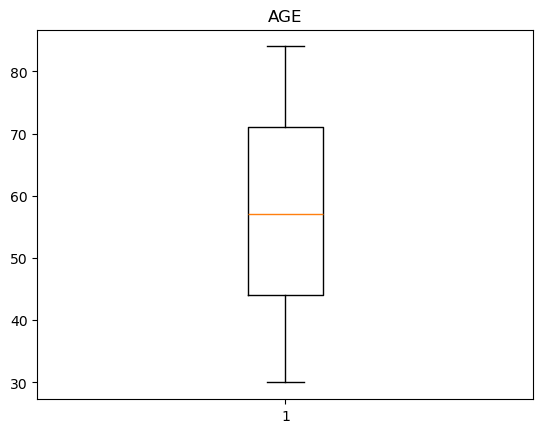

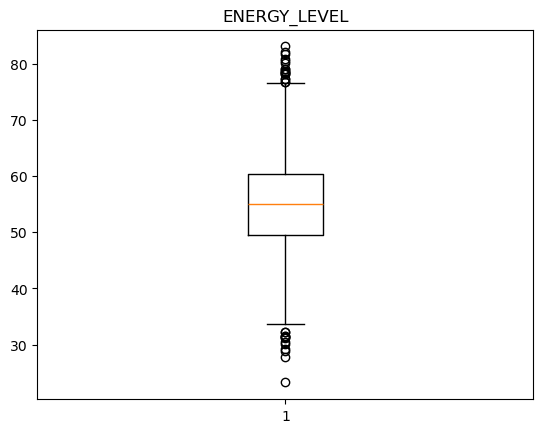

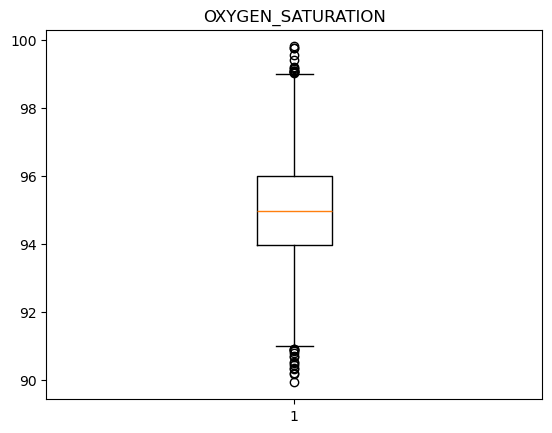

In [29]:
# checking outliers using boxplot
import matplotlib.pyplot as plt

for i in numeric_df:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [31]:
# Checking outliers using IQR

import numpy as np

# Select only numeric columns
numeric_cols = numeric_df.columns

# Dictionary to hold outlier indices for each column
outliers = {}

# IQR method to detect outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find indices of outliers
    outlier_indices = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outliers[col] = outlier_indices.tolist()

# Print the number of outliers in each column
for col, indices in outliers.items():
    print(f"{col}: {len(indices)} outliers")


AGE: 0 outliers
ENERGY_LEVEL: 31 outliers
OXYGEN_SATURATION: 30 outliers


In [33]:
df.describe()

,AGE,ENERGY_LEVEL,OXYGEN_SATURATION
count,5000.000000,5000.000000,5000.000000
mean,57.222800,55.032043,94.991029
std,15.799224,7.913083,1.481048
min,30.000000,23.258308,89.923133
25%,44.000000,49.440685,93.973176
50%,57.000000,55.050421,94.974073
75%,71.000000,60.323320,95.989272
max,84.000000,83.046971,99.795786


## Splitting into training and testing

In [35]:
from sklearn.model_selection import train_test_split

# Step 1: Prepare data
X = df.drop('PULMONARY_DISEASE', axis=1)
y = df['PULMONARY_DISEASE']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 4000
Testing set size: 1000


In [39]:
import pandas as pd

# Assuming X_train and y_train are already defined
# Concatenate X_train and y_train along columns
train_df = pd.concat([X_train, y_train], axis=1)

In [41]:
# no.of individuals with disease
print(len(train_df[train_df["PULMONARY_DISEASE"]=="YES"]))

# % of individuals with disease
(len(train_df[train_df["PULMONARY_DISEASE"]=="YES"])/len(train_df["PULMONARY_DISEASE"]))*100

1608


40.2

In [43]:
# no.of individuals without disease
print(len(train_df[train_df["PULMONARY_DISEASE"]=="NO"]))

# % of individuals without disease
(len(train_df[train_df["PULMONARY_DISEASE"]=="NO"])/len(train_df["PULMONARY_DISEASE"]))*100

2392


59.8

## Numerical Variables

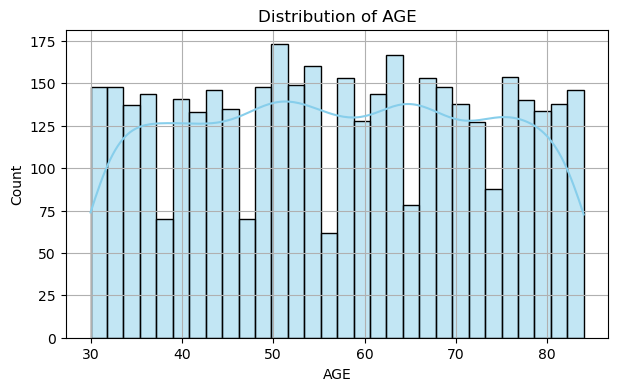

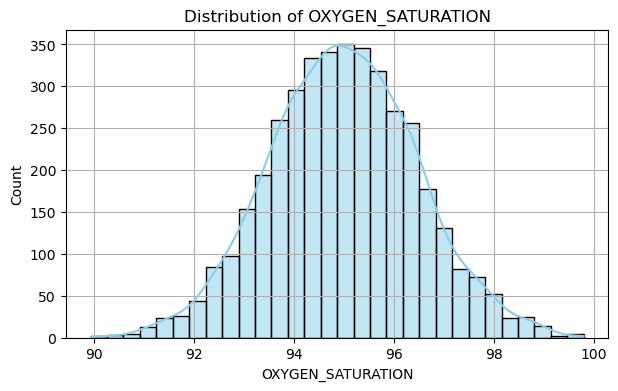

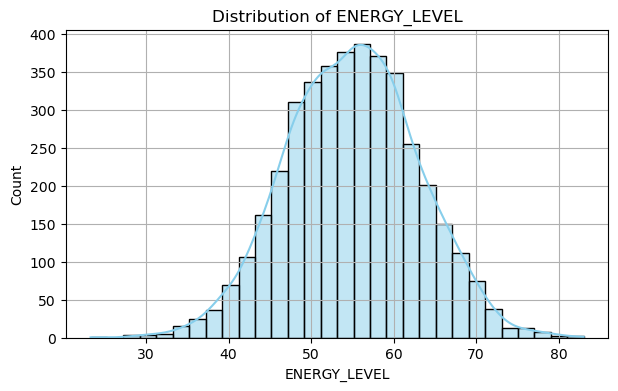

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_vars = ["AGE", "OXYGEN_SATURATION", "ENERGY_LEVEL"]

for col in numerical_vars:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=train_df, x=col, kde=True, bins=30, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

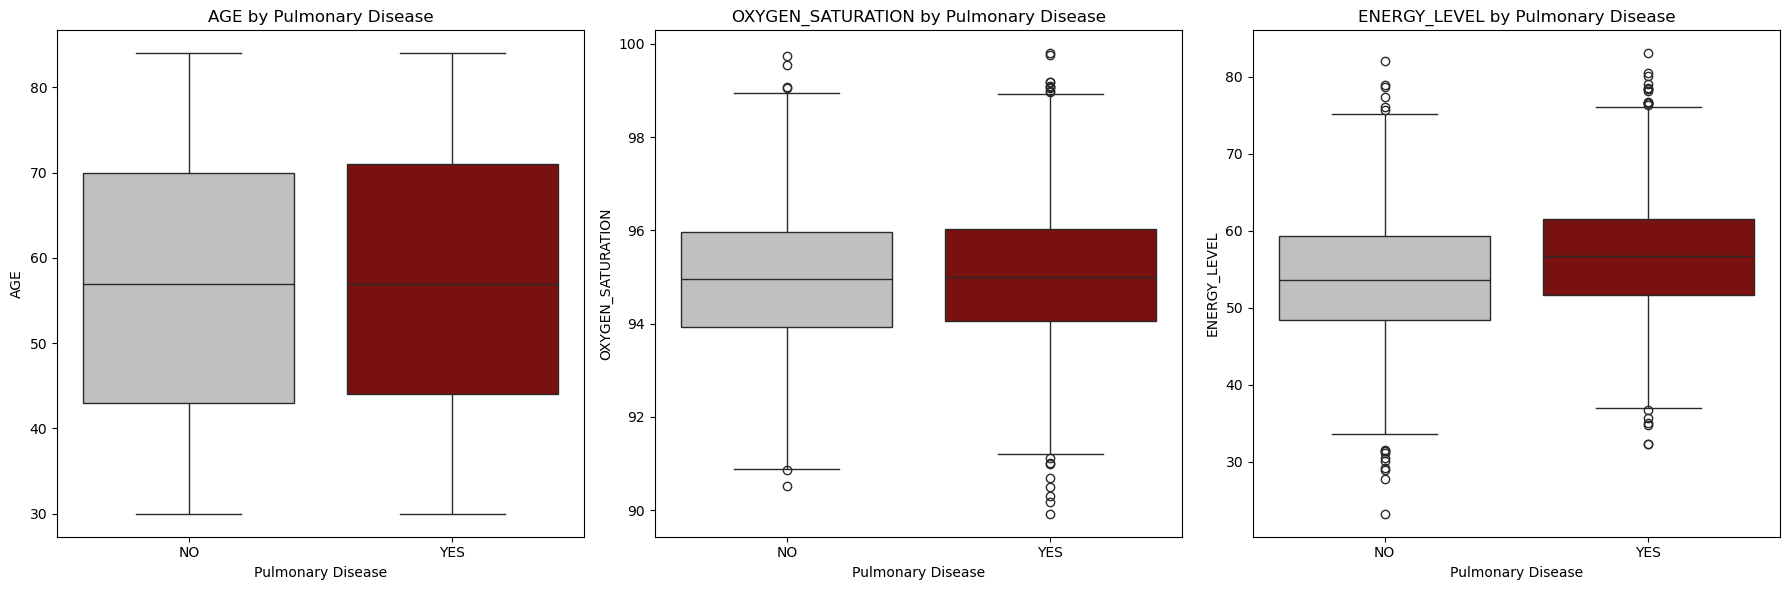

In [48]:
# Distribution of each numerical variable by pulmonary disease

import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# List of numerical variables
num_vars = ["AGE", "OXYGEN_SATURATION", "ENERGY_LEVEL"]

# Custom color palette: dark red for "YES", silver for "NO"
custom_palette = {"YES": "#8B0000", "NO": "#C0C0C0"}

# Create boxplots with hue and custom palette
for i, var in enumerate(num_vars):
    sns.boxplot(
        x="PULMONARY_DISEASE", y=var, hue="PULMONARY_DISEASE",
        data=train_df, ax=axes[i], palette=custom_palette, dodge=False, legend=False
    )
    axes[i].set_title(f"{var} by Pulmonary Disease")
    axes[i].set_xlabel("Pulmonary Disease")
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()


In [50]:
# hypothesis test

from scipy.stats import mannwhitneyu

# List of numerical variables
num_vars = ["AGE", "OXYGEN_SATURATION", "ENERGY_LEVEL"]

# Loop through each variable and perform t-test
for var in num_vars:
    group_yes = train_df[train_df["PULMONARY_DISEASE"] == "YES"][var].dropna()
    group_no = train_df[train_df["PULMONARY_DISEASE"] == "NO"][var].dropna()

    u_stat, p_val = mannwhitneyu(group_yes, group_no, alternative='two-sided')
    
    print(f"\nVariable: {var}")
    print(f"  p-value: {p_val:.4f}")
    
    if p_val < 0.05:
        print(" Significant difference between groups (Reject H₀)")
    else:
        print(" No significant difference (Fail to reject H₀)")



Variable: AGE
  p-value: 0.4934
 No significant difference (Fail to reject H₀)

Variable: OXYGEN_SATURATION
  p-value: 0.0874
 No significant difference (Fail to reject H₀)

Variable: ENERGY_LEVEL
  p-value: 0.0000
 Significant difference between groups (Reject H₀)


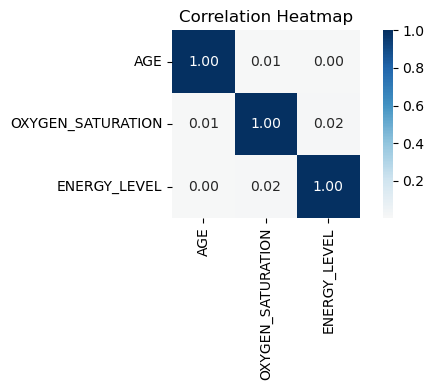

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numerical variables
num_vars = ["AGE", "OXYGEN_SATURATION", "ENERGY_LEVEL"]
corr = train_df[num_vars].corr()

# Example with 'RdBu' color map
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='RdBu', fmt=".2f", square=True, center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## Categorical Variables

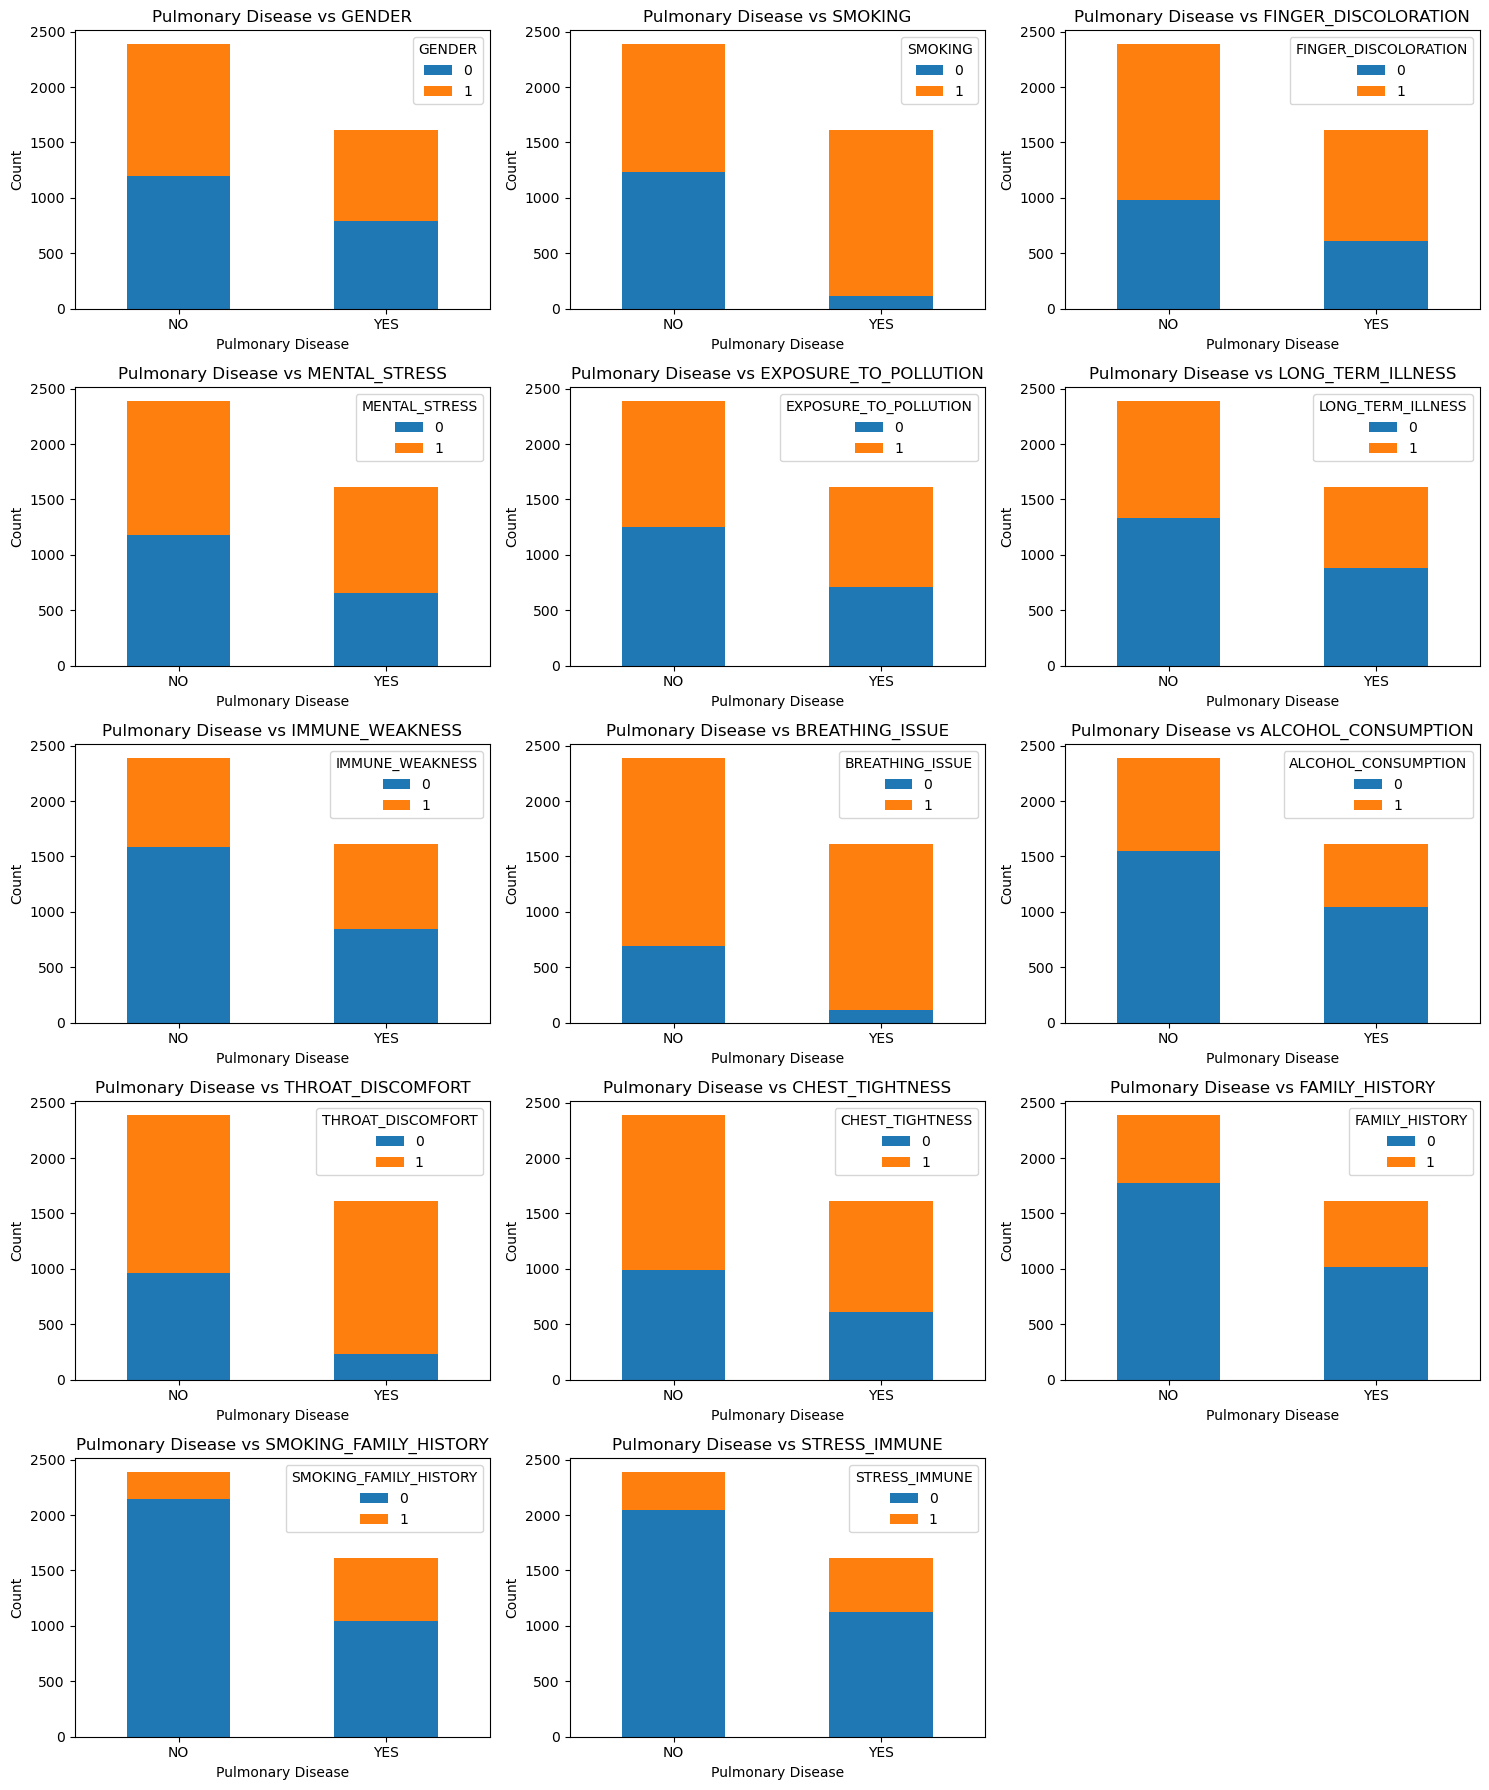

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# List of columns to exclude
exclude_columns = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION', 'PULMONARY_DISEASE']

# Select columns that are not in the exclude list
categorical_columns = [col for col in train_df.columns if col not in exclude_columns]

# Create a figure with 3 rows and 5 columns for subplots
nrows = 5
ncols = 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 18))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Loop through each categorical column and plot
for i, col in enumerate(categorical_columns):
    # Group by the categorical column and pulmonary disease status, count the occurrences
    df_grouped = train_df.groupby(['PULMONARY_DISEASE', col], observed=False).size().unstack()

    # Plot the stacked bar chart
    df_grouped.plot(kind='bar', stacked=True, ax=axes[i])

    # Add titles and labels
    axes[i].set_title(f'Pulmonary Disease vs {col}')
    axes[i].set_xlabel('Pulmonary Disease')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=360)  # Adjusts the x-axis labels for better readability

# If there are any unused subplots, turn them off
for j in range(i+1, len(axes)):
    axes[j].axis('off')

# Adjust the layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd
from pandas.api.types import CategoricalDtype

# List of columns to exclude
exclude_columns = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION', 'PULMONARY_DISEASE']

# Select categorical columns not in exclude list (updated to use non-deprecated method)
categorical_columns = [col for col in train_df.columns 
                      if col not in exclude_columns 
                      and isinstance(train_df[col].dtype, CategoricalDtype)]

# Verify target column exists and is binary
if 'PULMONARY_DISEASE' not in train_df.columns:
    available_cols = [c for c in train_df.columns if c not in exclude_columns]
    raise ValueError(f"'PULMONARY_DISEASE' column not found. Available columns: {available_cols}")

# Perform Chi-Square Test for each feature
results = []
for feature in categorical_columns:
    try:
        # Create contingency table with observed frequencies
        contingency_table = pd.crosstab(train_df[feature], train_df['PULMONARY_DISEASE'])
        
        # Check for validity of contingency table
        if contingency_table.empty or (contingency_table == 0).all().all():
            print(f"⚠️ Skipping {feature} - insufficient data variation")
            continue
            
        # Check expected frequencies (all cells should have >=5 for reliable chi-square)
        _, _, _, expected = chi2_contingency(contingency_table)
        if (expected < 5).any():
            print(f"⚠️ Warning for {feature}: Some expected frequencies <5 (chi-square may be unreliable)")
            
        # Perform Chi-Square Test
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        # Calculate effect size (Cramer's V)
        n = contingency_table.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * min(contingency_table.shape[0]-1, contingency_table.shape[1]-1)))
        
        # Store comprehensive results
        results.append({
            'Feature': feature,
            'Chi-Square': round(chi2, 3),
            'p-value': f"{p_value:.4f}",
            'Significant (α=0.05)': 'Yes' if p_value < 0.05 else 'No',
            'Effect Size (Cramer\'s V)': round(cramers_v, 3),
            'Degrees of Freedom': dof,
            'Sample Size': n,
            'Warning': 'Low expected freq' if (expected < 5).any() else ''
        })
        
    except Exception as e:
        print(f"❌ Error processing {feature}: {str(e)}")
        continue

# Display results
if results:
    results_df = pd.DataFrame(results)
    print("\n" + "="*80)
    print("CHI-SQUARE TEST RESULTS".center(80))
    print("="*80)
    display(results_df.sort_values(by='p-value'))
    
    # Print interpretation guide
    print("\nInterpretation Guide:")
    print("- p-value < 0.05 suggests significant association")
    print("- Cramer's V: 0.1=small, 0.3=medium, 0.5=large effect")
    print("- Warnings indicate when chi-square assumptions may be violated")
else:
    print("No valid results generated. Please check:")
    print("- Target variable encoding (should be categorical/binary)")
    print("- Feature variables (should have variation)")
    print(f"- Current categorical columns: {categorical_columns}")

In [ ]:

# List of columns to exclude
exclude_columns = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION', 'PULMONARY_DISEASE']

# Select columns that are not in the exclude list
categorical_columns = [col for col in train_df.columns if col not in exclude_columns]

# Perform Chi-Square Test for each feature
results = []
for feature in categorical_columns:
    # Create contingency table
    contingency_columns = pd.crosstab(train_df[feature], train_df['Pulmonary_Disease'])
    
    # Perform Chi-Square Test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Determine significance (using alpha = 0.05)
    significant = "Yes" if p_value < 0.05 else "No"
    
    # Store results
    results.append({
        'Feature': feature,
        'Chi-Square Statistic': chi2,
        'p-value': p_value,
        'Significant (p < 0.05)': significant
    })

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results)
print(results_df)

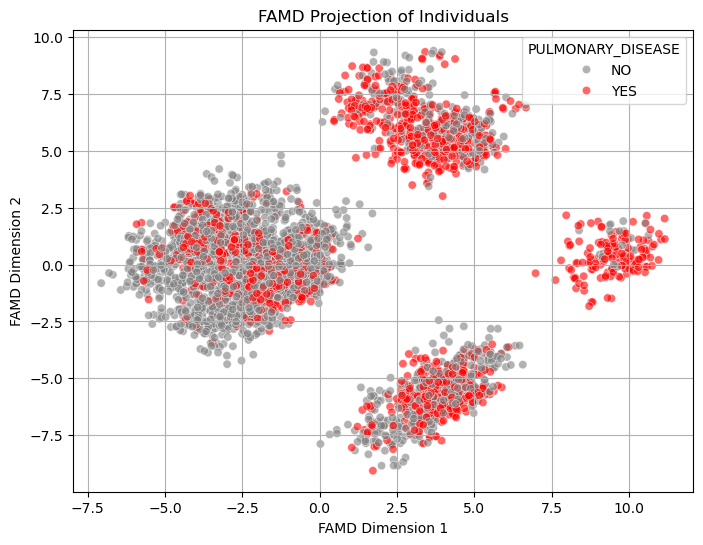

k = 2 → Silhouette Score: 0.542
k = 3 → Silhouette Score: 0.658
k = 4 → Silhouette Score: 0.689
k = 5 → Silhouette Score: 0.471
k = 6 → Silhouette Score: 0.433
k = 7 → Silhouette Score: 0.475
k = 8 → Silhouette Score: 0.459
k = 9 → Silhouette Score: 0.422
k = 10 → Silhouette Score: 0.408


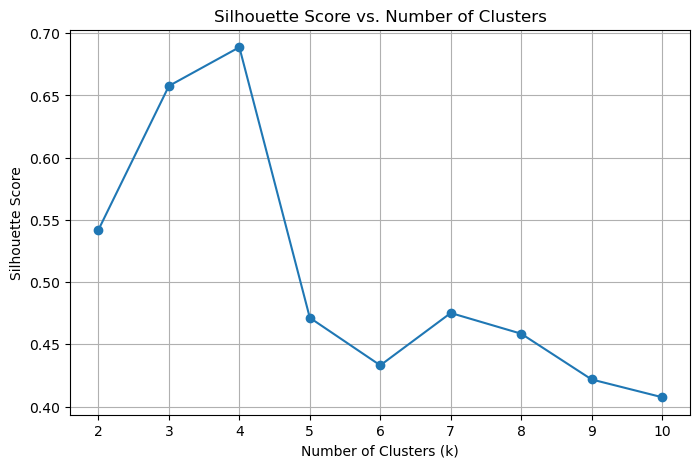

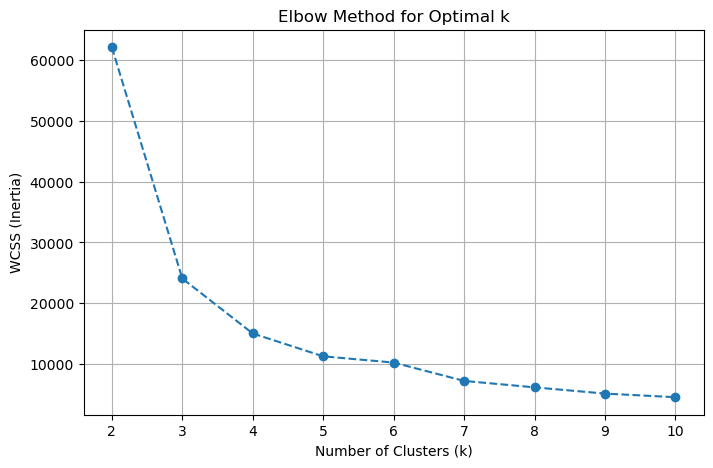

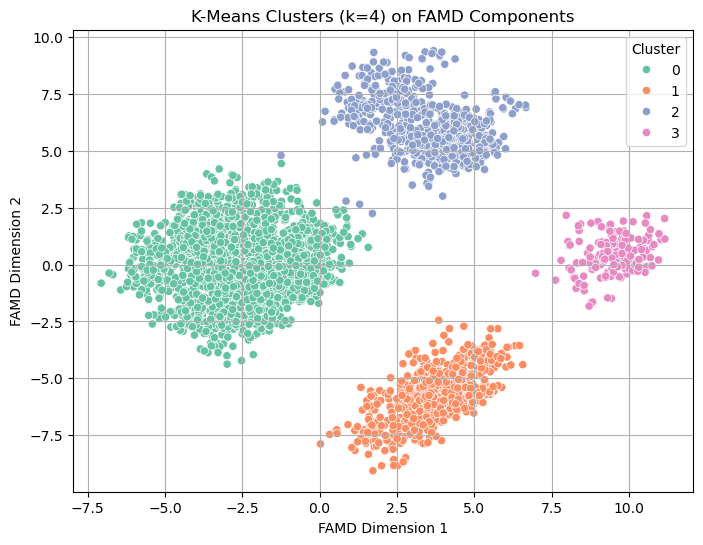

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince

# Step 2: Identify variable types
numerical_vars = ["AGE", "OXYGEN_SATURATION", "ENERGY_LEVEL"]
categorical_vars = [col for col in X_train.columns if col not in numerical_vars]

# Step 3: Convert categoricals to 'category'
X_train_famd = X_train.copy()
for col in categorical_vars:
    X_train_famd[col] = X_train_famd[col].astype("category")

# Step 4: Fit FAMD (2D)
famd = prince.FAMD(n_components=2, random_state=42)
famd = famd.fit(X_train_famd)
famd_coords = famd.transform(X_train_famd)  # This is a DataFrame

# Step 5: Plot FAMD individuals (optional color by target)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=famd_coords[0], y=famd_coords[1], hue=y_train, palette={'YES': 'red', 'NO': 'gray'}, alpha=0.6)
plt.title("FAMD Projection of Individuals")
plt.xlabel("FAMD Dimension 1")
plt.ylabel("FAMD Dimension 2")
plt.grid(True)
plt.legend(title="PULMONARY_DISEASE")
plt.show()

# Step 6: Determine optimal number of clusters (Silhouette Score)
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(famd_coords)
    score = silhouette_score(famd_coords, labels)
    silhouette_scores.append(score)
    print(f"k = {k} → Silhouette Score: {score:.3f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.grid(True)
plt.show()

# Step 7: Elbow Method
wcss = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(famd_coords)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# Step 8: Apply KMeans with chosen k (say k=4 from silhouette/elbow)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
famd_coords["Cluster"] = kmeans_final.fit_predict(famd_coords)

# Step 9: Visualize Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=famd_coords[0], y=famd_coords[1], hue=famd_coords["Cluster"], palette="Set2")
plt.xlabel("FAMD Dimension 1")
plt.ylabel("FAMD Dimension 2")
plt.title(f"K-Means Clusters (k={optimal_k}) on FAMD Components")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()